In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mne

In [ ]:
scan_length = [499, 692, 499, 692]
ch_names = ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8',
            'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Oz', 'TP9', 'TP10', 'POz']
labels   = pd.read_csv('splits/labels_64_dictionary.csv')
networks = labels['Yeo_networks7'].values

In [5]:
attn = np.load('attn.npy')

In [8]:
n_ch    = len(ch_names)          # 23
n_heads = attn.shape[-1] // n_ch # 736 // 23 = 32
attn_ch = attn[..., :n_heads * n_ch].reshape(2382, 64, n_heads, n_ch).mean(axis=2)
# attn_ch: (2382, 64, 23)

scan_splits = np.split(attn_ch, np.cumsum(scan_length[:-1]), axis=0)
attn_mean = np.stack([s.mean(axis=0) for s in scan_splits], axis=0).mean(axis=0)

In [9]:
print(attn_mean.shape)

(64, 23)


In [10]:
montage = mne.channels.make_standard_montage('standard_1020')
info    = mne.create_info(ch_names=ch_names, sfreq=1.0, ch_types='eeg')
info.set_montage(montage)

# get 2D channel positions for peak marker
pos_2d = np.array([info['chs'][i]['loc'][:2] for i in range(len(ch_names))])

In [11]:
NETWORK_ORDER = ['VisCent', 'SomMotA', 'SalVentAttnA', 'DefaultB']

NETWORK_LABELS = {
    'VisCent':      'Visual',
    'SomMotA':      'Somatomotor',
    'DefaultB':     'Default Mode',
    'SalVentAttnA': 'Salience',
}

NETWORK_COLORS = {
    'VisCent':      '#8E9AAF',
    'SomMotA':      '#CBC0D3',
    'DefaultB':     '#FEC89A',
    'SalVentAttnA': '#EFD3D7',
}

In [12]:
net_attn = {}
for net in NETWORK_ORDER:
    roi_idx = np.where(networks == net)[0]
    if len(roi_idx) == 0:
        continue
    v = attn_mean[roi_idx].mean(axis=0)
    net_attn[net] = (v - v.min()) / (v.max() - v.min() + 1e-8)

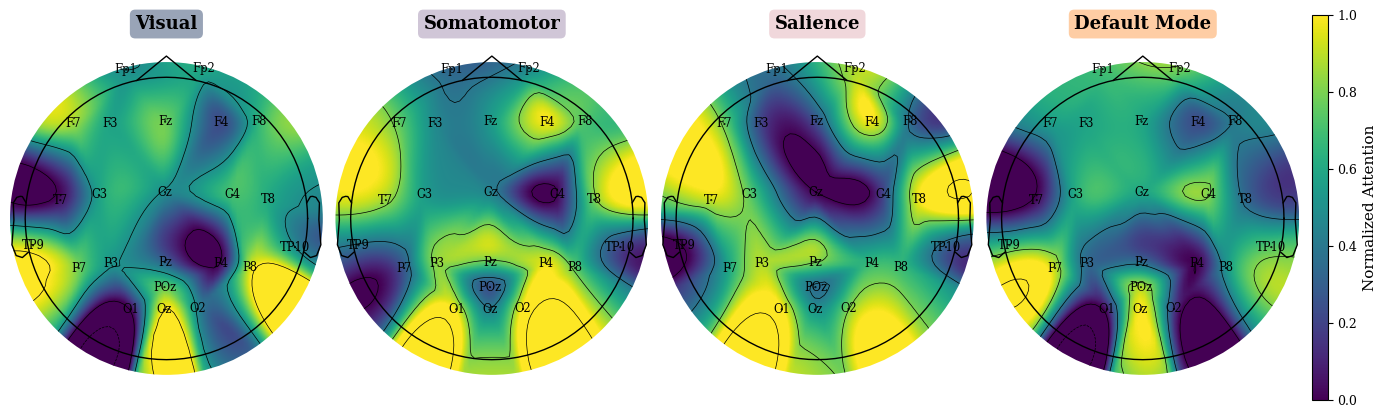

In [13]:
plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        12,
    'axes.titleweight': 'bold',
    'axes.titlesize':   13,
})

fig = plt.figure(figsize=(17, 5))
gs  = gridspec.GridSpec(1, 5,
                        width_ratios=[1, 1, 1, 1, 0.05],
                        wspace=0.05)

axes = [fig.add_subplot(gs[0, i]) for i in range(4)]
cax  = fig.add_subplot(gs[0, -1])

for ax, net in zip(axes, NETWORK_ORDER):
    data = net_attn[net]

    im, _ = mne.viz.plot_topomap(
        data, info,
        axes=ax,
        show=False,
        contours=4,
        cmap='viridis',
        vlim=(0.0, 1.0),
        sensors=True,
        names=ch_names,
    )

    ax.set_title(NETWORK_LABELS[net], fontsize=13, pad=8,
                 bbox=dict(boxstyle='round,pad=0.3',
                           facecolor=NETWORK_COLORS[net],
                           edgecolor='none', alpha=0.9))

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('Normalized Attention', fontsize=11)
cbar.ax.tick_params(labelsize=9)

plt.savefig('attn_topomap.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('attn_topomap.png', dpi=300, bbox_inches='tight')
plt.show()